NAME:PRIYADHARSHINI MURUGAN


MY APP LINK:https://priyadharshinisyntecxapphouseprediction-qn6nzwga6ahtk2maxj9bzm.streamlit.app/

In [33]:
# Clone the GitHub repository
!git clone https://github.com/Priyadh1/syntecxhub_houseprediction_project.git

# Move into the project folder
%cd syntecxhub_houseprediction_project

Cloning into 'syntecxhub_houseprediction_project'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 22 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 150.82 KiB | 2.90 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/syntecxhub_houseprediction_project/syntecxhub_houseprediction_project


In [34]:
import os

print("Project files:")
for file in os.listdir():
    print("-", file)

Project files:
- app.py
- house_price_prediction.csv
- README.md
- .git
- requirements.txt
- house_price_model.pkl


In [35]:
#DATASET LOADING
import pandas as pd

df = pd.read_csv("house_price_prediction.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 7045
Columns: 13


,House_ID,Property_Code,Area_Sqft,Bedrooms,Bathrooms,Age_Years,Location,Furnishing_Status,Property_Type,Parking_Spaces,Garden_Available,Distance_To_City_Center_Km,Price
0,1,HP-2018-10000,2548.0,1,1,5.0,Urban,Semi-Furnished,Studio,3,0,3.6,428225.0
1,2,HP-2019-10001,2103.0,2,1,2.0,Suburban,Semi-Furnished,Apartment,1,0,1.3,414559.0
2,3,HP-2020-10002,2653.0,3,2,3.0,Urban,Semi-Furnished,Apartment,2,0,3.0,560716.0
3,4,HP-2021-10003,3266.0,4,3,3.0,Suburban,Semi-Furnished,Villa,1,1,3.2,775550.0
4,5,HP-2022-10004,2036.0,2,1,16.0,Urban,Semi-Furnished,Independent House,1,0,8.3,429372.0


In [36]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House_ID                    7045 non-null   int64  
 1   Property_Code               7045 non-null   object 
 2   Area_Sqft                   6835 non-null   float64
 3   Bedrooms                    7045 non-null   int64  
 4   Bathrooms                   7045 non-null   int64  
 5   Age_Years                   6835 non-null   float64
 6   Location                    7045 non-null   object 
 7   Furnishing_Status           6835 non-null   object 
 8   Property_Type               7045 non-null   object 
 9   Parking_Spaces              7045 non-null   int64  
 10  Garden_Available            7045 non-null   int64  
 11  Distance_To_City_Center_Km  6833 non-null   float64
 12  Price                       7045 non-null   float64
dtypes: float64(4), int64(5), object(4

In [37]:
# Check missing values
df.isnull().sum()

,0
House_ID,0
Property_Code,0
Area_Sqft,210
Bedrooms,0
Bathrooms,0
Age_Years,210
Location,0
Furnishing_Status,210
Property_Type,0
Parking_Spaces,0


In [38]:
# CLEAN THE MISSING VALUES
# Create a copy for cleaning
clean_df = df.copy()

# Fill numerical missing values with median
numeric_columns = [
    "Area_Sqft",
    "Age_Years",
    "Distance_To_City_Center_Km"
]

for col in numeric_columns:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Fill categorical missing values with mode
clean_df["Furnishing_Status"] = clean_df["Furnishing_Status"].fillna(
    clean_df["Furnishing_Status"].mode()[0]
)

print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
House_ID                      0
Property_Code                 0
Area_Sqft                     0
Bedrooms                      0
Bathrooms                     0
Age_Years                     0
Location                      0
Furnishing_Status             0
Property_Type                 0
Parking_Spaces                0
Garden_Available              0
Distance_To_City_Center_Km    0
Price                         0
dtype: int64


In [39]:
# Statistical summary of the dataset
clean_df.describe()

,House_ID,Area_Sqft,Bedrooms,Bathrooms,Age_Years,Parking_Spaces,Garden_Available,Distance_To_City_Center_Km,Price
count,7045.000000,7045.000000,7045.000000,7045.000000,7045.000000,7045.000000,7045.000000,7045.000000,7.045000e+03
mean,3499.533712,2226.382849,3.353584,2.074379,11.913020,1.344500,0.408517,8.137242,5.192220e+05
std,2021.173256,786.399065,1.222321,0.905926,12.053431,0.851469,0.491594,8.683489,1.394974e+05
min,1.000000,500.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.500000,7.071700e+04
25%,1751.000000,1747.000000,2.000000,1.000000,4.000000,1.000000,0.000000,2.400000,4.275810e+05
50%,3497.000000,2201.000000,3.000000,2.000000,8.000000,1.000000,0.000000,5.500000,5.126030e+05
75%,5252.000000,2658.000000,4.000000,3.000000,16.000000,2.000000,1.000000,11.100000,6.002990e+05
max,7000.000000,10901.358123,6.000000,5.000000,108.084513,3.000000,1.000000,215.994605,1.768638e+06


In [40]:
# Explore categorical features

print("Location:")
print(clean_df["Location"].value_counts())

print("\nFurnishing Status:")
print(clean_df["Furnishing_Status"].value_counts())

print("\nProperty Type:")
print(clean_df["Property_Type"].value_counts())

Location:
Location
Urban       2436
Suburban    2139
Downtown    1420
Rural       1050
Name: count, dtype: int64

Furnishing Status:
Furnishing_Status
Semi-Furnished     2548
Unfurnished        1779
Furnished          1646
SEMI-FURNISHED      100
Semi_Furnished       95
semi-furnished       95
furnished            89
#Semi-Furnished      85
Furnished            74
Semi Furnished       72
 Furnished           66
 Unfurnished         65
unfurnished          61
FURNISHED            59
UNFURNISHED          57
#Furnished           56
#Unfurnished         50
Un-furnished         48
Name: count, dtype: int64

Property Type:
Property_Type
Apartment            3182
Independent House    1730
Villa                1104
Studio               1029
Name: count, dtype: int64


In [41]:
# Standardize Furnishing_Status categories

clean_df["Furnishing_Status"] = (
    clean_df["Furnishing_Status"]
    .str.strip()
    .str.lower()
    .str.replace("-", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace("#", "", regex=False)
)

# Convert variations into standard category names
clean_df["Furnishing_Status"] = clean_df["Furnishing_Status"].replace({
    "semifurnished": "Semi-Furnished",
    "furnished": "Furnished",
    "unfurnished": "Unfurnished"
})

print(clean_df["Furnishing_Status"].value_counts())

Furnishing_Status
Semi-Furnished    2995
Unfurnished       2060
Furnished         1990
Name: count, dtype: int64


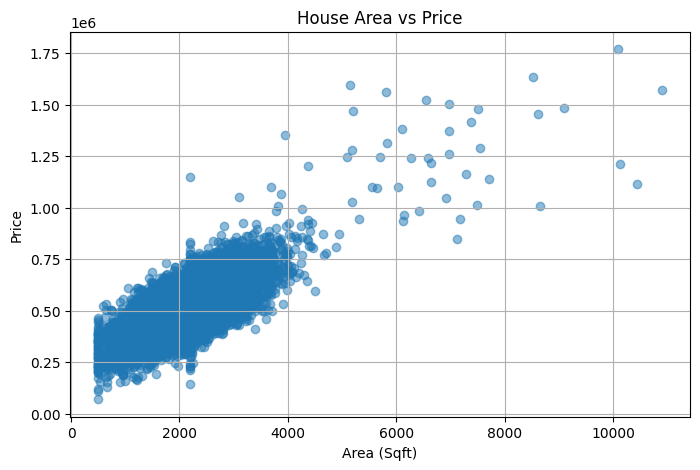

In [42]:
# EDA VISUALIZATION CHARTS
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(clean_df["Area_Sqft"], clean_df["Price"], alpha=0.5)
plt.xlabel("Area (Sqft)")
plt.ylabel("Price")
plt.title("House Area vs Price")
plt.grid(True)
plt.show()

In [43]:
# Check duplicate rows

duplicate_count = clean_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 44


In [44]:

#EDA
# Remove duplicate rows

before = len(clean_df)

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

after = len(clean_df)

print("Rows before removing duplicates:", before)
print("Duplicate rows removed:", before - after)
print("Rows after removing duplicates:", after)

Rows before removing duplicates: 7045
Duplicate rows removed: 44
Rows after removing duplicates: 7001


In [45]:
# Verify duplicate removal

print("Duplicate rows remaining:", clean_df.duplicated().sum())

Duplicate rows remaining: 0


In [46]:
# Check unique values in categorical columns

categorical_columns = [
    "Location",
    "Furnishing_Status",
    "Property_Type"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(clean_df[col].unique())


Location:
['Urban' 'Suburban' 'Rural' 'Downtown']

Furnishing_Status:
['Semi-Furnished' 'Unfurnished' 'Furnished']

Property_Type:
['Studio' 'Apartment' 'Villa' 'Independent House']


In [47]:
# Check minimum and maximum values of important numerical features

numerical_columns = [
    "Area_Sqft",
    "Bedrooms",
    "Bathrooms",
    "Age_Years",
    "Parking_Spaces",
    "Garden_Available",
    "Distance_To_City_Center_Km",
    "Price"
]

for col in numerical_columns:
    print(f"{col}:")
    print("  Minimum:", clean_df[col].min())
    print("  Maximum:", clean_df[col].max())

Area_Sqft:
  Minimum: 500.0
  Maximum: 10901.358123266278
Bedrooms:
  Minimum: 1
  Maximum: 6
Bathrooms:
  Minimum: 1
  Maximum: 5
Age_Years:
  Minimum: 0.0
  Maximum: 108.08451272528474
Parking_Spaces:
  Minimum: 0
  Maximum: 3
Garden_Available:
  Minimum: 0
  Maximum: 1
Distance_To_City_Center_Km:
  Minimum: 0.5
  Maximum: 215.99460508204209
Price:
  Minimum: 70717.0
  Maximum: 1768637.702366092


In [48]:
# Check potential outliers using the IQR method

outlier_columns = [
    "Area_Sqft",
    "Age_Years",
    "Distance_To_City_Center_Km",
    "Price"
]

for col in outlier_columns:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[col] < lower_bound) |
        (clean_df[col] > upper_bound)
    ]

    print(f"\n{col}")
    print("Lower bound:", round(lower_bound, 2))
    print("Upper bound:", round(upper_bound, 2))
    print("Potential outliers:", len(outliers))


Area_Sqft
Lower bound: 383.0
Upper bound: 4023.0
Potential outliers: 78

Age_Years
Lower bound: -14.0
Upper bound: 34.0
Potential outliers: 420

Distance_To_City_Center_Km
Lower bound: -10.65
Upper bound: 24.15
Potential outliers: 360

Price
Lower bound: 169832.0
Upper bound: 858816.0
Potential outliers: 86


In [49]:
# Correlation analysis for numerical features

correlation = clean_df.select_dtypes(include="number").corr()["Price"].sort_values(
    ascending=False
)

print(correlation)

Price                         1.000000
Area_Sqft                     0.753839
Bedrooms                      0.527146
Bathrooms                     0.478970
Parking_Spaces                0.050887
Garden_Available              0.039979
House_ID                     -0.019975
Distance_To_City_Center_Km   -0.043387
Age_Years                    -0.130503
Name: Price, dtype: float64


In [50]:
# Feature selection

features = [
    "Area_Sqft",
    "Bedrooms",
    "Bathrooms",
    "Age_Years",
    "Location",
    "Furnishing_Status",
    "Property_Type",
    "Parking_Spaces",
    "Garden_Available",
    "Distance_To_City_Center_Km"
]

X = clean_df[features]
y = clean_df["Price"]

print("Features selected:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features selected:
['Area_Sqft', 'Bedrooms', 'Bathrooms', 'Age_Years', 'Location', 'Furnishing_Status', 'Property_Type', 'Parking_Spaces', 'Garden_Available', 'Distance_To_City_Center_Km']

Target:
Price

Feature shape: (7001, 10)
Target shape: (7001,)


In [51]:
from sklearn.model_selection import train_test_split

# First split: 70% training, 30% temporary data
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Second split: divide the remaining 30% equally
# → 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (4900, 10) (4900,)
Validation set: (1050, 10) (1050,)
Test set: (1051, 10) (1051,)


In [52]:
#PREPROCESSING AND ENCODING
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Numerical and categorical features
numeric_features = [
    "Area_Sqft",
    "Bedrooms",
    "Bathrooms",
    "Age_Years",
    "Parking_Spaces",
    "Garden_Available",
    "Distance_To_City_Center_Km"
]

categorical_features = [
    "Location",
    "Furnishing_Status",
    "Property_Type"
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test using the training-fitted encoder
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Validation processed shape:", X_val_processed.shape)
print("Test processed shape:", X_test_processed.shape)

Training processed shape: (4900, 15)
Validation processed shape: (1050, 15)
Test processed shape: (1051, 15)


In [53]:
from sklearn.linear_model import LinearRegression

# Create the Multiple Linear Regression model
model = LinearRegression()

# Train the model using ONLY the training data
model.fit(X_train_processed, y_train)

print("Multiple Linear Regression model trained successfully!")
print("Number of coefficients:", len(model.coef_))

Multiple Linear Regression model trained successfully!
Number of coefficients: 15


In [54]:
# Predict house prices on validation data
y_val_pred = model.predict(X_val_processed)

print("Validation predictions generated successfully!")
print("Number of predictions:", len(y_val_pred))

Validation predictions generated successfully!
Number of predictions: 1050


In [55]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Validation metrics
validation_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
validation_r2 = r2_score(y_val, y_val_pred)

print("Validation RMSE:", validation_rmse)
print("Validation R²:", validation_r2)

Validation RMSE: 31525.256430199643
Validation R²: 0.9504053894971828


In [56]:
# Final predictions on the untouched test set
y_test_pred = model.predict(X_test_processed)

# Final test metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Final Test RMSE:", test_rmse)
print("Final Test R²:", test_r2)

Final Test RMSE: 39134.59996287307
Final Test R²: 0.9241089227548369


In [57]:
#COEFFICIENT INTERPRETATION
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get model coefficients
coefficients = model.coef_

# Create coefficient table
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient for easier comparison
coefficient_df["Absolute_Coefficient"] = coefficient_df["Coefficient"].abs()

# Sort by absolute coefficient
coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

coefficient_df

,Feature,Coefficient,Absolute_Coefficient
0,cat__Property_Type_Villa,60886.866270,60886.866270
1,cat__Location_Rural,-58952.407751,58952.407751
2,num__Bedrooms,43431.948896,43431.948896
3,cat__Location_Suburban,-37973.995318,37973.995318
4,num__Bathrooms,30707.220226,30707.220226
5,cat__Property_Type_Independent House,30161.159245,30161.159245
6,cat__Location_Urban,-22594.458295,22594.458295
7,cat__Property_Type_Studio,-19981.221873,19981.221873
8,num__Garden_Available,14220.146239,14220.146239
9,num__Parking_Spaces,8126.260256,8126.260256


In [58]:
import joblib

# Save the preprocessing + trained model together
house_price_model = {
    "preprocessor": preprocessor,
    "model": model,
    "features": features
}

joblib.dump(house_price_model, "house_price_model.pkl")

print("Model saved successfully!")
print("File: house_price_model.pkl")

Model saved successfully!
File: house_price_model.pkl


In [59]:
import os

print("File exists:", os.path.exists("house_price_model.pkl"))
print("File size:", os.path.getsize("house_price_model.pkl"), "bytes")

File exists: True
File size: 4318 bytes


In [60]:
# Create a new house for prediction

new_house = pd.DataFrame({
    "Area_Sqft": [2500],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Age_Years": [5],
    "Location": ["Urban"],
    "Furnishing_Status": ["Furnished"],
    "Property_Type": ["Apartment"],
    "Parking_Spaces": [2],
    "Garden_Available": [1],
    "Distance_To_City_Center_Km": [5]
})

# Transform the new input using the trained preprocessor
new_house_processed = preprocessor.transform(new_house)

# Predict the house price
predicted_price = model.predict(new_house_processed)[0]

print("Predicted House Price:", round(predicted_price, 2))

Predicted House Price: 558993.45


In [61]:
# PREDICTION  SECTION
import ipywidgets as widgets
from IPython.display import display, clear_output

# Input fields
area = widgets.FloatText(value=2500, description="Area Sqft:")
bedrooms = widgets.IntSlider(value=3, min=1, max=6, description="Bedrooms:")
bathrooms = widgets.IntSlider(value=2, min=1, max=5, description="Bathrooms:")
age = widgets.FloatText(value=5, description="Age Years:")

location = widgets.Dropdown(
    options=["Downtown", "Urban", "Suburban", "Rural"],
    value="Urban",
    description="Location:"
)

furnishing = widgets.Dropdown(
    options=["Furnished", "Semi-Furnished", "Unfurnished"],
    value="Furnished",
    description="Furnishing:"
)

property_type = widgets.Dropdown(
    options=["Apartment", "Independent House", "Villa", "Studio"],
    value="Apartment",
    description="Property Type:"
)

parking = widgets.IntSlider(value=2, min=0, max=3, description="Parking:")
garden = widgets.Dropdown(
    options=[("Yes", 1), ("No", 0)],
    value=1,
    description="Garden:"
)

distance = widgets.FloatText(value=5, description="Distance Km:")

predict_button = widgets.Button(
    description="Predict House Price",
    button_style="success"
)

output = widgets.Output()

def predict_house_price(b):
    with output:
        clear_output()

        new_house = pd.DataFrame({
            "Area_Sqft": [area.value],
            "Bedrooms": [bedrooms.value],
            "Bathrooms": [bathrooms.value],
            "Age_Years": [age.value],
            "Location": [location.value],
            "Furnishing_Status": [furnishing.value],
            "Property_Type": [property_type.value],
            "Parking_Spaces": [parking.value],
            "Garden_Available": [garden.value],
            "Distance_To_City_Center_Km": [distance.value]
        })

        processed = preprocessor.transform(new_house)
        prediction = model.predict(processed)[0]

        print("🏠 HOUSE PRICE PREDICTION")
        print("-" * 35)
        print(f"Predicted Price: ₹{prediction:,.2f}")

predict_button.on_click(predict_house_price)

display(
    area,
    bedrooms,
    bathrooms,
    age,
    location,
    furnishing,
    property_type,
    parking,
    garden,
    distance,
    predict_button,
    output
)

FloatText(value=2500.0, description='Area Sqft:')

IntSlider(value=3, description='Bedrooms:', max=6, min=1)

IntSlider(value=2, description='Bathrooms:', max=5, min=1)

FloatText(value=5.0, description='Age Years:')

Dropdown(description='Location:', index=1, options=('Downtown', 'Urban', 'Suburban', 'Rural'), value='Urban')

...

IntSlider(value=2, description='Parking:', max=3)

Dropdown(description='Garden:', options=(('Yes', 1), ('No', 0)), value=1)

FloatText(value=5.0, description='Distance Km:')

Button(button_style='success', description='Predict House Price', style=ButtonStyle())

Output()

In [62]:
import sys
import sklearn
import numpy
import pandas
import joblib

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
scikit-learn: 1.6.1
NumPy: 2.1.3
Pandas: 2.2.3
Joblib: 1.6.0


In [63]:
# PREDICTION SECTION

import ipywidgets as widgets
from IPython.display import display, clear_output

# Input fields
area = widgets.FloatText(value=2500, description="Area Sqft:")
bedrooms = widgets.IntSlider(value=3, min=1, max=6, description="Bedrooms:")
bathrooms = widgets.IntSlider(value=2, min=1, max=5, description="Bathrooms:")
age = widgets.FloatText(value=5, description="Age Years:")

location = widgets.Dropdown(
    options=["Downtown", "Urban", "Suburban", "Rural"],
    value="Urban",
    description="Location:"
)

furnishing = widgets.Dropdown(
    options=["Furnished", "Semi-Furnished", "Unfurnished"],
    value="Furnished",
    description="Furnishing:"
)

property_type = widgets.Dropdown(
    options=["Apartment", "Independent House", "Villa", "Studio"],
    value="Apartment",
    description="Property Type:"
)

parking = widgets.IntSlider(
    value=2,
    min=0,
    max=3,
    description="Parking:"
)

garden = widgets.Dropdown(
    options=[("Yes", 1), ("No", 0)],
    value=1,
    description="Garden:"
)

distance = widgets.FloatText(
    value=5,
    description="Distance Km:"
)

predict_button = widgets.Button(
    description="Predict House Price",
    button_style="success"
)

output = widgets.Output()

def predict_house_price(b):
    with output:
        clear_output(wait=True)

        new_house = pd.DataFrame({
            "Area_Sqft": [area.value],
            "Bedrooms": [bedrooms.value],
            "Bathrooms": [bathrooms.value],
            "Age_Years": [age.value],
            "Location": [location.value],
            "Furnishing_Status": [furnishing.value],
            "Property_Type": [property_type.value],
            "Parking_Spaces": [parking.value],
            "Garden_Available": [garden.value],
            "Distance_To_City_Center_Km": [distance.value]
        })

        processed = preprocessor.transform(new_house)
        prediction = model.predict(processed)[0]

        print("🏠 HOUSE PRICE PREDICTION")
        print("-" * 35)
        print(f"Predicted Price: ₹{prediction:,.2f}")

predict_button.on_click(predict_house_price)

display(
    area,
    bedrooms,
    bathrooms,
    age,
    location,
    furnishing,
    property_type,
    parking,
    garden,
    distance,
    predict_button,
    output
)

FloatText(value=2500.0, description='Area Sqft:')

IntSlider(value=3, description='Bedrooms:', max=6, min=1)

IntSlider(value=2, description='Bathrooms:', max=5, min=1)

FloatText(value=5.0, description='Age Years:')

Dropdown(description='Location:', index=1, options=('Downtown', 'Urban', 'Suburban', 'Rural'), value='Urban')

...

IntSlider(value=2, description='Parking:', max=3)

Dropdown(description='Garden:', options=(('Yes', 1), ('No', 0)), value=1)

FloatText(value=5.0, description='Distance Km:')

Button(button_style='success', description='Predict House Price', style=ButtonStyle())

Output()